## 정규분포 데이터 생성하고 이상치 추가해보기

In [ ]:
## 데이터 계산 및 시각화 library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
## 통계함수 library
from scipy.stats import mode, norm

Text(0.5, 1.0, 'outlier')

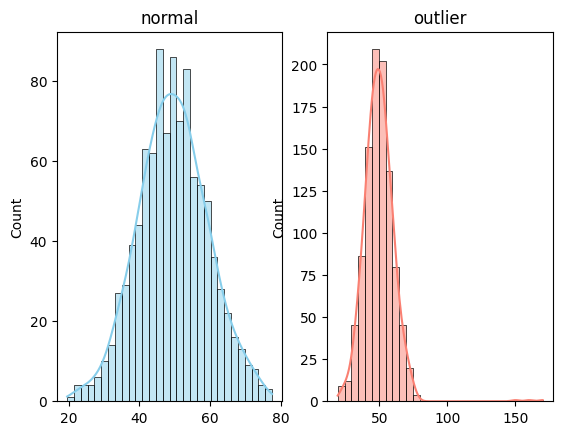

In [ ]:
## 정규분포 데이터 생성
np.random.seed(0)
data_normal = np.random.normal(loc=50, scale=10, size=1000) # mu=50, sd=10

## 이상치 추가
## 원본 데이터 뒤에 (150,160,170) 극단적으로 큰 값 3개 추가
data_with_outliers = np.append(data_normal, [150, 160, 170])

## 이상치에 따른 분포 변화를 명확하게 보기 위해
## 평균, 중앙값 계산
def calculate_stats(data):
  mean_val = np.mean(data)
  median_val = np.median(data)
  return mean_val, median_val

## 이상치 추가 전/후 계산
mean_n, median_n = calculate_stats(data_normal)
mean_o, median_o = calculate_stats(data_with_outliers)


## 히스토그램 그리기
## 원본데이터
plt.subplot(1, 2, 1)
sns.histplot(data_normal, bins=30, kde=True, color='skyblue')
plt.title('normal')

## 이상치 포함 데이터
plt.subplot(1, 2, 2)
sns.histplot(data_with_outliers, bins=30, kde=True, color='salmon')
plt.title('outlier')

## Z-score를 이용한 이상치 탐지
- 평균 기반 이상치 탐지
- Z-score 절댓값이 3보다 크면 이상치로 간주
- 즉, 정규분포 기준 약 99.7%가 +-3 이내 -> 그 외는 극단값으로 취급

In [ ]:
## 데이터 생성
np.random.seed(42)
data = np.random.normal(50, 10, 1000)

## 이상치 추가
data = np.append(data, [150, 160, 170])

df = pd.DataFrame({'value': data})

In [ ]:
## Z-score: 평균 기반 이상치 탐지
## 평균과 표준편차 계산
mean = df['value'].mean()
std = df['value'].std()

## Z-score 계산
df['z_score'] = (df['value'] - mean) / std

## 이상치 여부 판단
df['outlier_z'] = df['z_score'].abs() > 3

In [ ]:
mean

np.float64(50.521755292346214)

In [ ]:
std

11.480036761806645

In [ ]:
df.outlier_z.value_counts()

,count
outlier_z,
False,999
True,4


Text(0.5, 1.0, 'Z-score')

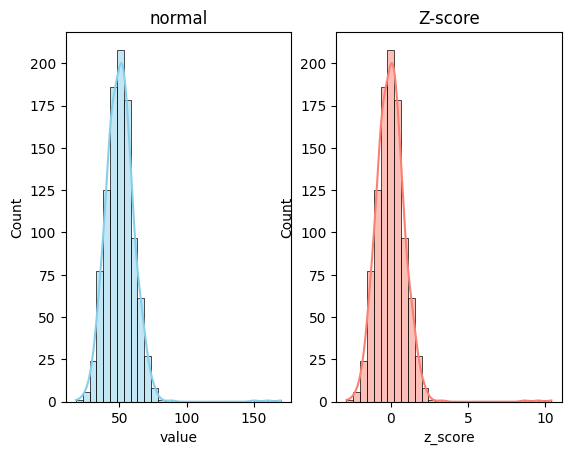

In [ ]:
## 원본과 z-score분포 시각화
## 원본 subplot
plt.subplot(1, 2, 1)
sns.histplot(df['value'], bins=30, kde=True, color='skyblue')
plt.title('normal')

## z-score subplot
plt.subplot(1, 2, 2)
sns.histplot(df['z_score'], bins=30, kde=True, color='salmon')
plt.title('Z-score')

## IQR 기반 이상치 탐지

In [ ]:
## 사분위수 계산
Q1 = df['value'].quantile(0.25)
Q3 = df['value'].quantile(0.75)

## IQR 계산
IQR = Q3 - Q1

## 기본 IQR 기준 이상치 경계
lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR

## 이상치 여부 판단
df['outlier_iqr'] = (df['value'] < lower_bound) | (df['value'] > upper_bound)

In [ ]:
## 더 엄격한 IQR 기준
lower_bound_1 = Q1 - 3*IQR
upper_bound_1 = Q3 + 3*IQR

## 엄격 기준 이상치 여부 판단
df['outlier_iqr_1'] = (df['value'] < lower_bound_1) | (df['value'] > upper_bound_1)

In [ ]:
print(Q1, Q3, IQR)

43.54153680576175 56.5079621463223 12.966425340560548


In [ ]:
lower_bound

np.float64(24.09189879492093)

In [ ]:
upper_bound

np.float64(75.95760015716311)

In [ ]:
df.outlier_iqr.value_counts()

,count
outlier_iqr,
False,992
True,11


In [ ]:
df.outlier_iqr_1.value_counts()

,count
outlier_iqr_1,
False,1000
True,3


In [ ]:
df

,value,z_score,outlier_z,outlier_iqr,outlier_iqr_1
0,54.967142,0.387228,False,False,False
1,48.617357,-0.165888,False,False,False
2,56.476885,0.518738,False,False,False
3,65.230299,1.281228,False,False,False
4,47.658466,-0.249415,False,False,False
...,...,...,...,...,...
998,44.288210,-0.542990,False,False,False
999,55.725828,0.453315,False,False,False
1000,150.000000,8.665325,True,True,True
1001,160.000000,9.536402,True,True,True


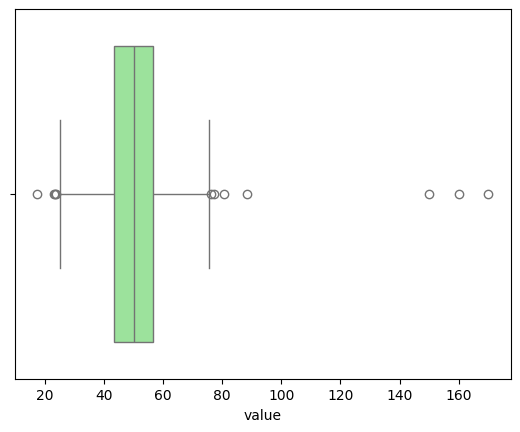

In [ ]:
## boxplot을 활용하여 시각화
sns.boxplot(x=df['value'], color ='lightgreen')
plt.show()

## 공정 데이터(Temperature, Pressure, Speed, DefectRate) 예제

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
## 랜덤 시드 고정
np.random.seed(42)

## 데이터 생성
n_samples = 500
data = pd.DataFrame({
    'Temperature': np.random.normal(100, 5, n_samples),  # 평균 100°C, 표준편차 5
    'Pressure': np.random.normal(200, 10, n_samples),    # 평균 200kPa, 표준편차 10
    'Speed': np.random.normal(1500, 50, n_samples),      # 평균 1500rpm, 표준편차 50
    'DefectRate': np.random.normal(2, 0.5, n_samples)    # 평균 2%, 표준편차 0.5
})

## 이상치 추가
data.loc[10, 'Temperature'] = 200  # 온도 이상치
data.loc[20, 'Pressure'] = 300     # 압력 이상치
data.loc[30, 'Speed'] = 1000       # 속도 이상치
data.loc[40, 'DefectRate'] = 10    # 결함율 이상치

## 데이터 확인
print(data.head())

   Temperature    Pressure        Speed  DefectRate
0   102.483571  209.261775  1569.967772    2.389181
1    99.308678  219.094166  1546.231684    1.724407
2   103.238443  186.014324  1502.981518    1.590901
3   107.615149  205.629692  1467.653161    1.998313
4    98.829233  193.493574  1534.911166    1.914908


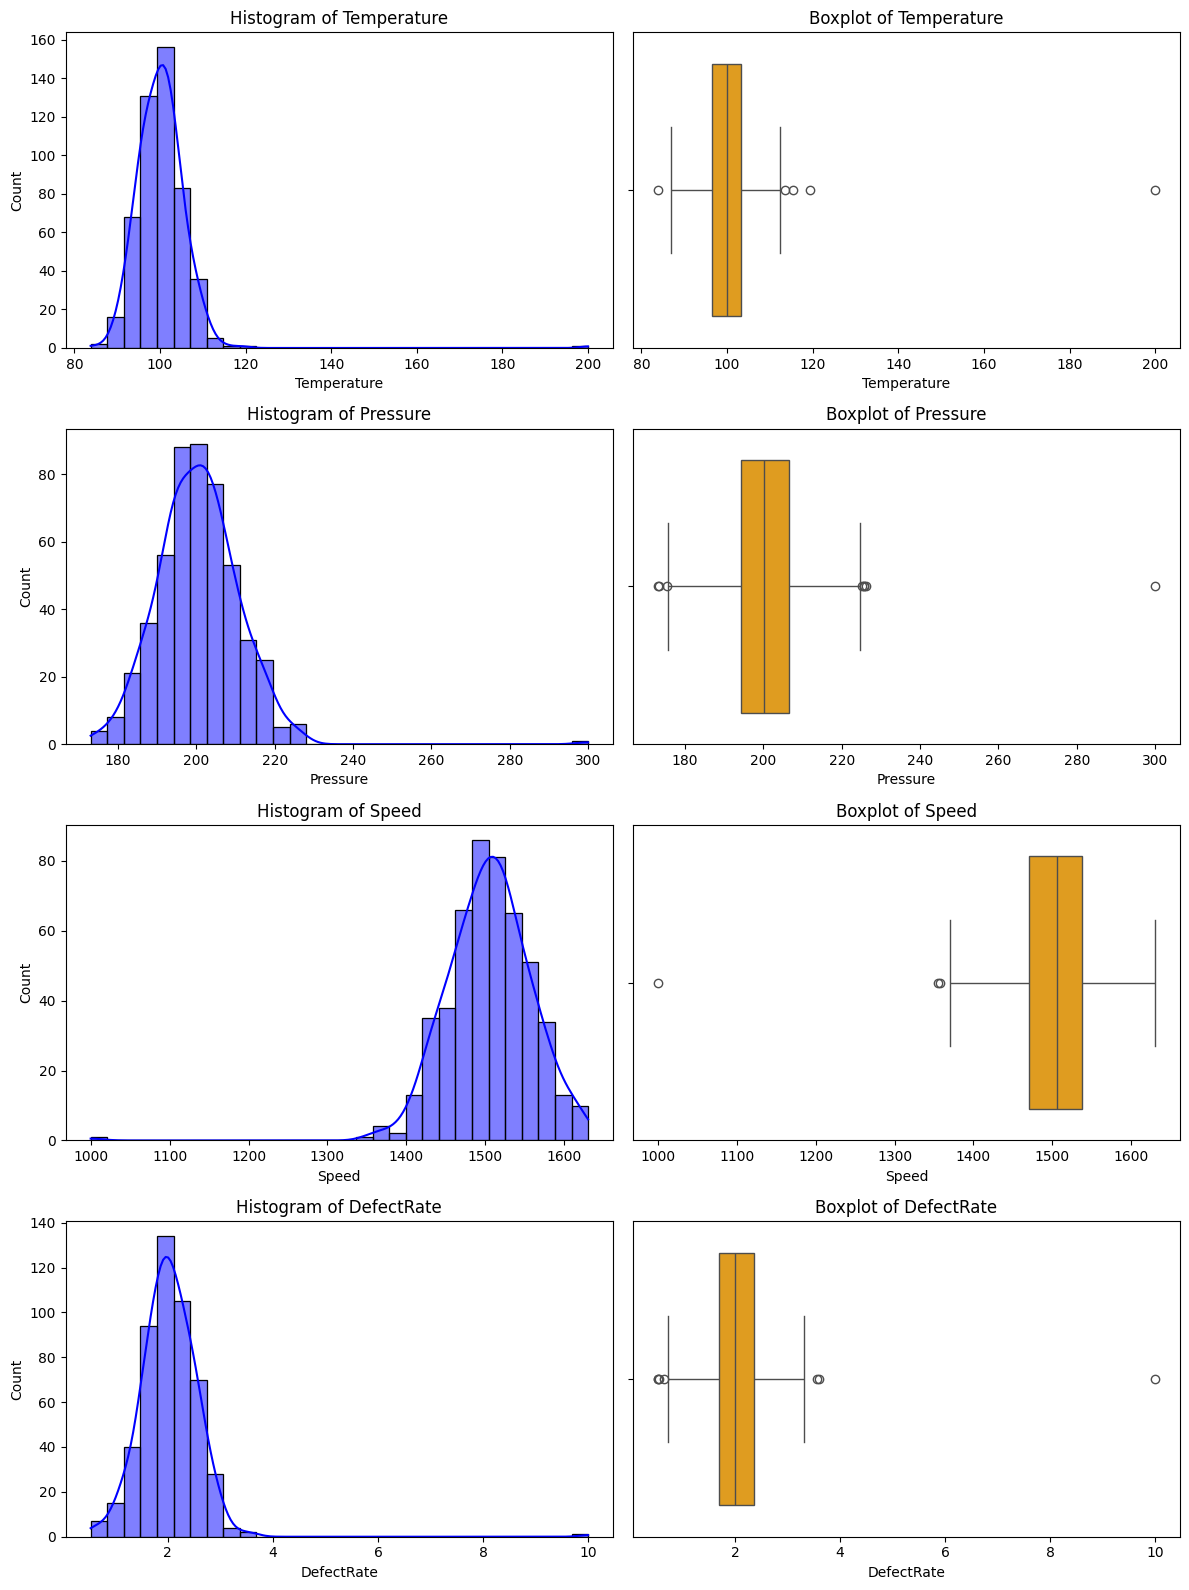

In [ ]:
## 이상치의 데이터 분포 시각화
fig, axes = plt.subplots(4, 2, figsize=(12, 16))

columns = ['Temperature', 'Pressure', 'Speed', 'DefectRate']

## 반복문으로 hist & boxplot 그리기
for i, column in enumerate(data.columns):
  # histogram
  sns.histplot(data[column], bins=30, ax=axes[i, 0], kde=True, color='blue')
  axes[i, 0].set_title(f"Histogram of {column}")

  # boxplot
  sns.boxplot(x=data[column], ax=axes[i, 1], color='orange')
  axes[i, 1].set_title(f"Boxplot of {column}")

plt.tight_layout()
plt.show()

In [ ]:
## IQR 방식으로 이상치 탐지
def detect_outlier_iqr(df, column):
  Q1 = np.percentile(df[column], 25)
  Q3 = np.percentile(df[column], 75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5*IQR
  upper_bound = Q3 + 1.5*IQR
  return df[(df[column] < lower_bound) | (df[column] > upper_bound)]

In [ ]:
## dictionary 컴프리헨션
outliers_iqr = {col: detect_outlier_iqr(data, col) for col in data.columns}
outliers_iqr['Temperature']

,Temperature,Pressure,Speed,DefectRate
10,200.000000,202.704568,1565.869703,1.429155
179,113.600846,212.715551,1444.820534,1.784190
209,119.263657,216.964564,1587.478837,1.512735
262,83.793663,225.600845,1526.937800,2.037717
478,115.394404,184.160972,1455.625391,1.613561


## Isolation Forest 알고리즘
- 이상치 탐지를 위해 고안된 비지도 학습 기반 앙상블 트리 모델
- 랜덤하게 feature와 분할값을 선택하여 데이터를 분리하는 방식
- 이상치는 적은 분할로도 쉽게 격리되므로 빠르게 탐지 가능

## 주요 하이퍼파라미터 (Parameters)
- 파라미터	설명
    - n_estimators	트리 개수 (default: 100)
    - max_samples	각 트리에서 사용할 샘플 수. int, float, or "auto" (default: "auto").
    "auto"는 min(256, n_samples)
    - contamination	이상치의 예상 비율. float 또는 "auto" 가능. 예: 0.05는 5% 이상치
    - max_features	각 트리에서 사용할 feature의 비율 또는 개수
    - bootstrap	부트스트랩 샘플링 여부 (True 또는 False)
    - random_state	난수 시드 설정
    - n_jobs	병렬 처리 시 사용할 CPU 코어 수. -1이면 전체 사용
    - verbose	로깅 출력 정도 (0, 1, 2)
    - warm_start	True이면 이전에 학습된 트리를 유지하고 추가 트리 학습 가능

## 주요 속성 (Attributes)
- 속성	설명
    - estimators_	학습된 트리 객체 리스트
    - offset_	이상치 점수 임계값 (threshold). contamination 비율에 따라 자동 계산됨
    - threshold_	이상치 탐지 기준 점수
    - n_features_in_	학습 데이터의 feature 수
    - feature_names_in_	입력 feature 이름들 (pandas 기반 입력 시)

In [ ]:
## Isolation Forest 기반 탐지
from sklearn.ensemble import IsolationForest

## 전체 샘플 중 1%를 이상치로 간주
iso = IsolationForest(contamination=0.01, random_state=111)
outlier_flages = iso.fit_predict(data)

In [ ]:
## 이상치 행 추출
outlier_iso = data[outlier_flags == -1]
outlier_iso

,Temperature,Pressure,Speed,DefectRate
10,200.000000,202.704568,1565.869703,1.429155
20,107.328244,300.000000,1526.141774,2.610517
40,103.692333,208.356921,1584.196385,10.000000
209,119.263657,216.964564,1587.478837,1.512735
471,88.490394,193.189483,1469.510855,0.529806


In [ ]:
## Rule-Based 방식
def detect_outliers_rule_based(df):
    conditions = (
    (df['Temperature']>120) |
    (df['Pressure']>250) |
    (df['Speed']>1500)   |
    (df['DefectRate']>7)
    )
    return df[conditions]

In [ ]:
## 이상치 행 추출
outliers_rule = detect_outliers_rule_based(data)
outliers_rule

,Temperature,Pressure,Speed,DefectRate
0,102.483571,209.261775,1569.967772,2.389181
1,99.308678,219.094166,1546.231684,1.724407
2,103.238443,186.014324,1502.981518,1.590901
4,98.829233,193.493574,1534.911166,1.914908
5,98.829315,195.128746,1519.674269,1.773386
...,...,...,...,...
495,102.694550,197.188997,1600.304644,2.535075
496,94.813769,217.976865,1603.075179,1.986739
497,99.048307,206.408429,1560.418312,1.559063
498,95.621909,194.288210,1551.203126,1.918467
